# Birds Biodiversity Analysis - Martinique Breeding Bird Monitoring (2012-2025)

This notebook implements the complete analysis for the Applied Statistics final project.

## Project Overview
- **Dataset**: Martinique Breeding Bird Monitoring, 2012-2025
- **Data Source**: Excel workbook with 3 sheets (ESPECES, GPS-MILIEU, NOM FRANÇAIS)
- **Objective**: Analyze bird observation data to understand biodiversity patterns, trends, and relationships

## Tasks Covered
1. Data Loading and Exploration
2. Exploratory Data Analysis (EDA)
3. Statistical Modeling and Analysis
4. Advanced Analysis
5. Results Interpretation and Reporting


In [19]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)


print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.4


## Task 1: Data Loading and Exploration

### 1.1 Load Excel Workbook


In [20]:
!pwd
!ls

/Users/moujar/Dev/MasterParisSaclay/T1/Applied Statistics/project/Statistical-ML-DL-Showdown/projects/birds-biodiversity
birds_biodiversity_analysis.ipynb fix_species_col.py
data                              HYPOTHESES_AND_TASKS.md
dataset_overview.md               PROJECT_SUMMARY_AND_TASKS.md
final_project_assignment.pdf      TASK_STATUS_REPORT.md


In [21]:
# Define data path (relative to notebook directory)
data_path = "data/raw/data.xlsx"

# First, check available sheets in the Excel file
print("Inspecting Excel workbook structure...")
try:
    # Read Excel file to get all sheet names
    xl_file = pd.ExcelFile(data_path)
    print(f"✓ Excel file found: {data_path}")
    print(f"✓ Available sheets: {xl_file.sheet_names}")
    print(f"✓ Number of sheets: {len(xl_file.sheet_names)}")
    
    # Load all sheets - try common sheet name variations
    sheet_names = xl_file.sheet_names
    
    # Try to match expected sheet names (case-insensitive)
    especies_sheet = None
    gps_milieu_sheet = None
    observations_sheet = None
    
    for sheet in sheet_names:
        sheet_lower = sheet.lower()
        if 'especes' in sheet_lower or 'especies' in sheet_lower:
            especies_sheet = sheet
        elif 'gps' in sheet_lower and 'milieu' in sheet_lower:
            gps_milieu_sheet = sheet
        elif 'nom' in sheet_lower and 'francais' in sheet_lower or 'français' in sheet_lower:
            observations_sheet = sheet
    
    # If exact matches not found, use first 3 sheets
    if not especies_sheet:
        especies_sheet = sheet_names[0] if len(sheet_names) > 0 else None
    if not gps_milieu_sheet:
        gps_milieu_sheet = sheet_names[1] if len(sheet_names) > 1 else None
    if not observations_sheet:
        observations_sheet = sheet_names[2] if len(sheet_names) > 2 else None
    
    print(f"\nLoading sheets:")
    print(f"  - ESPECES: {especies_sheet}")
    print(f"  - GPS-MILIEU: {gps_milieu_sheet}")
    print(f"  - NOM FRANÇAIS: {observations_sheet}")
    
    # Load all three sheets
    especies_df = pd.read_excel(data_path, sheet_name=especies_sheet)
    gps_milieu_df = pd.read_excel(data_path, sheet_name=gps_milieu_sheet)
    observations_df = pd.read_excel(data_path, sheet_name=observations_sheet)
    
    print(f"\n✓ ESPECES sheet loaded: {especies_df.shape[0]} rows, {especies_df.shape[1]} columns")
    print(f"✓ GPS-MILIEU sheet loaded: {gps_milieu_df.shape[0]} rows, {gps_milieu_df.shape[1]} columns")
    print(f"✓ NOM FRANÇAIS sheet loaded: {observations_df.shape[0]} rows, {observations_df.shape[1]} columns")
    
except FileNotFoundError:
    print(f"ERROR: File not found at {data_path}")
    print("Please ensure the Excel file is in the correct location: data/raw/data.xlsx")
    import os
    print(f"Current working directory: {os.getcwd()}")
    print(f"Absolute path would be: {os.path.abspath(data_path)}")
except Exception as e:
    print(f"Error loading data: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()


Inspecting Excel workbook structure...
✓ Excel file found: data/raw/data.xlsx
✓ Available sheets: ['ESPECES', 'GPS-MILIEU', 'NOM FRANÇAIS']
✓ Number of sheets: 3

Loading sheets:
  - ESPECES: ESPECES
  - GPS-MILIEU: GPS-MILIEU
  - NOM FRANÇAIS: NOM FRANÇAIS

✓ ESPECES sheet loaded: 86 rows, 5 columns
✓ GPS-MILIEU sheet loaded: 651 rows, 8 columns
✓ NOM FRANÇAIS sheet loaded: 114497 rows, 26 columns


### 1.2 Explore Data Structure


In [29]:
# Explore ESPECES (Species) sheet
print("=" * 80)
print("ESPECES Sheet - Species Taxonomy")
print("=" * 80)
print(f"\nShape: {especies_df.shape}")
print(f"\nColumns: {list(especies_df.columns)}")
print(f"\nFirst few rows:")
display(especies_df.head())
print(f"\nData types:")
print(especies_df.dtypes)
print(f"\nInfo:")
especies_df.info()



ESPECES Sheet - Species Taxonomy

Shape: (86, 5)

Columns: ['Unnamed: 0', 'Unnamed: 1', 'Aigrette bleue', 'Egretta caerulea', 'Migrateur']

First few rows:


,Unnamed: 0,Unnamed: 1,Aigrette bleue,Egretta caerulea,Migrateur
0,NaN,NaN,Aigrette garzette,Egretta garzetta,Migrateur
1,NaN,NaN,Aigrette neigeuse,Egretta thula,Migrateur
2,NaN,NaN,Aigrette tricolore,Egretta tricolor ruficollis,Migrateur
3,NaN,NaN,Amazone aourou,Amazona amazonica,Exogène introduit par l'homme
4,NaN,NaN,Astrild à joues orange,Estrilda melpoda,NaN



Data types:
Unnamed: 0          float64
Unnamed: 1          float64
Aigrette bleue       object
Egretta caerulea     object
Migrateur            object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        0 non-null      float64
 1   Unnamed: 1        0 non-null      float64
 2   Aigrette bleue    86 non-null     object 
 3   Egretta caerulea  86 non-null     object 
 4   Migrateur         85 non-null     object 
dtypes: float64(2), object(3)
memory usage: 3.5+ KB


In [36]:
# Explore GPS-MILIEU (Site Catalog) sheet
print("=" * 80)
print("GPS-MILIEU Sheet - Site Catalog")
print("=" * 80)
print(f"\nShape: {gps_milieu_df.shape}")
print(f"\nColumns: {list(gps_milieu_df.columns)}")
print(f"\nFirst few rows:")
display(gps_milieu_df.head())
print(f"\nData types:")
print(gps_milieu_df.dtypes)
print(f"\nInfo:")
gps_milieu_df.info()


GPS-MILIEU Sheet - Site Catalog

Shape: (651, 8)

Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'WGS84 UTM 20', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']

First few rows:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,WGS84 UTM 20,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,Transect,X,Y,NaN,NaN,NaN
1,NaN,NaN,Aéroport,714593,1614233,Mangrove,S1,SIPI
2,NaN,NaN,Aéroport,714416,1614194,Mangrove,S1,S1P2
3,NaN,NaN,Aéroport,714133,1614141,Mangrove,S1,S1P3
4,NaN,NaN,Aéroport,713914,1614103,Mangrove,S1,S1P4



Data types:
Unnamed: 0      float64
Unnamed: 1      float64
Unnamed: 2       object
WGS84 UTM 20     object
Unnamed: 4       object
Unnamed: 5       object
Unnamed: 6       object
Unnamed: 7       object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    0 non-null      float64
 1   Unnamed: 1    0 non-null      float64
 2   Unnamed: 2    651 non-null    object 
 3   WGS84 UTM 20  651 non-null    object 
 4   Unnamed: 4    651 non-null    object 
 5   Unnamed: 5    650 non-null    object 
 6   Unnamed: 6    650 non-null    object 
 7   Unnamed: 7    650 non-null    object 
dtypes: float64(2), object(6)
memory usage: 40.8+ KB


In [42]:
# Explore NOM FRANÇAIS (Observations) sheet
print("=" * 80)
print("NOM FRANÇAIS Sheet - Observation Log")
print("=" * 80)
print(f"\nShape: {observations_df.shape}")
print(f"\nColumns: {list(observations_df.columns)}")
print(f"\nFirst few rows:")
display(observations_df.head())
print(f"\nData types:")
print(observations_df.dtypes)
print(f"\nInfo:")
observations_df.info()


NOM FRANÇAIS Sheet - Observation Log

Shape: (114497, 26)

Columns: ['Nom observateur', 'code département', 'Nom transect', 'date', '1er, 2e ou 3e passage', 'nuages', 'pluie', 'vent', 'visibilité', 'N° point', 'heure début', 'ESPECE', 'distances de contact', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'totaux', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']

First few rows:


,Nom observateur,code département,Nom transect,date,"1er, 2e ou 3e passage",nuages,pluie,vent,visibilité,N° point,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,totaux,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,<100m,NaN,> 100m,NaN,vol,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Auditif,Visuel,Auditif,Visuel,NaN,Auditif,"Visuel (sans""Vol"")","A+V (sans ""Vol"")","A+V (avec ""Vol"")",NaN
2,BELFAN David,972.0,Fond l'Etang,2014-04-12 00:00:00,1.0,2,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,1,0,1,1,NaN
3,BELFAN David,972.0,Fond l'Etang,2014-04-12 00:00:00,1.0,2,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,0,1,1,1,NaN
4,BELFAN David,972.0,Fond l'Etang,2014-04-12 00:00:00,1.0,2,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,0,2,2,2,NaN



Data types:
Nom observateur           object
code département         float64
Nom transect              object
date                      object
1er, 2e ou 3e passage    float64
nuages                    object
pluie                    float64
vent                     float64
visibilité               float64
N° point                 float64
heure début               object
ESPECE                    object
distances de contact      object
Unnamed: 13               object
Unnamed: 14               object
Unnamed: 15               object
Unnamed: 16               object
Unnamed: 17               object
Unnamed: 18               object
Unnamed: 19               object
Unnamed: 20               object
totaux                    object
Unnamed: 22               object
Unnamed: 23               object
Unnamed: 24               object
Unnamed: 25               object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114497 entries, 0 to 114496
Data columns (total 26 columns

In [47]:
# Function to check data quality
def data_quality_report(df, name):
    """Generate a comprehensive data quality report"""
    print(f"\n{'='*80}")
    print(f"Data Quality Report: {name}")
    print(f"{'='*80}")
    
    print(f"\n1. Basic Statistics:")
    print(f"   - Total rows: {len(df):,}")
    print(f"   - Total columns: {len(df.columns)}")
    print(f"   - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\n2. Missing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print("   ✓ No missing values found!")
    
    print(f"\n3. Duplicate Rows:")
    duplicates = df.duplicated().sum()
    print(f"   - Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")
    
    print(f"\n4. Data Types:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   - {dtype}: {count} columns")
    
    return missing_df

# Generate quality reports for all sheets
missing_especies = data_quality_report(especies_df, "ESPECES")
missing_gps = data_quality_report(gps_milieu_df, "GPS-MILIEU")
missing_obs = data_quality_report(observations_df, "NOM FRANÇAIS")



Data Quality Report: ESPECES

1. Basic Statistics:
   - Total rows: 86
   - Total columns: 5
   - Memory usage: 0.02 MB

2. Missing Values:


,Column,Missing Count,Missing %
0,Unnamed: 0,86,100.00
1,Unnamed: 1,86,100.00
4,Migrateur,1,1.16



3. Duplicate Rows:
   - Duplicate rows: 1 (1.16%)

4. Data Types:
   - object: 3 columns
   - float64: 2 columns

Data Quality Report: GPS-MILIEU

1. Basic Statistics:
   - Total rows: 651
   - Total columns: 8
   - Memory usage: 0.21 MB

2. Missing Values:


,Column,Missing Count,Missing %
0,Unnamed: 0,651,100.00
1,Unnamed: 1,651,100.00
5,Unnamed: 5,1,0.15
6,Unnamed: 6,1,0.15
7,Unnamed: 7,1,0.15



3. Duplicate Rows:
   - Duplicate rows: 0 (0.00%)

4. Data Types:
   - object: 6 columns
   - float64: 2 columns

Data Quality Report: NOM FRANÇAIS

1. Basic Statistics:
   - Total rows: 114,497
   - Total columns: 26
   - Memory usage: 95.13 MB

2. Missing Values:


,Column,Missing Count,Missing %
19,Unnamed: 19,113108,98.79
17,Unnamed: 17,112965,98.66
20,Unnamed: 20,112675,98.41
18,Unnamed: 18,111847,97.69
15,Unnamed: 15,109064,95.25
16,Unnamed: 16,106093,92.66
25,Unnamed: 25,103625,90.50
14,Unnamed: 14,83347,72.79
13,Unnamed: 13,75305,65.77
12,distances de contact,55664,48.62



3. Duplicate Rows:
   - Duplicate rows: 2,243 (1.96%)

4. Data Types:
   - object: 20 columns
   - float64: 6 columns


### 1.4 Merge Sheets


In [51]:
# Identify merge keys by examining column names
print("Identifying merge keys...")

# Find potential species code column
species_cols = [col for col in observations_df.columns if 'species' in col.lower() or 'code' in col.lower()]
print(f"Potential species columns in observations: {species_cols}")

# Find potential location columns
location_cols = [col for col in observations_df.columns if 'transect' in col.lower() or 'point' in col.lower()]
print(f"Potential location columns in observations: {location_cols}")

# Merge observations with species information
# First, identify the actual column names (adjust based on actual data)
# This is a template - adjust column names based on actual data structure

# Example merge (adjust column names based on actual data):
# merged_df = observations_df.merge(
#     especies_df, 
#     left_on='species_code', 
#     right_on='species_code', 
#     how='left',
#     suffixes=('', '_species')
# )

# merged_df = merged_df.merge(
#     gps_milieu_df,
#     left_on=['transect_id', 'point_id'],
#     right_on=['transect_id', 'point_id'],
#     how='left',
#     suffixes=('', '_site')
# )

print("\nNote: Adjust merge keys based on actual column names in your data")
print("Once merged, the dataset will be ready for analysis")


Identifying merge keys...
Potential species columns in observations: ['code département']
Potential location columns in observations: ['Nom transect', 'N° point']

Note: Adjust merge keys based on actual column names in your data
Once merged, the dataset will be ready for analysis


In [52]:
# Validate that each transect has 10 points
# Adjust column names based on actual data structure

print("Validating data assumptions...")

# Check transect-point structure in GPS-MILIEU
if 'transect_id' in gps_milieu_df.columns and 'point_id' in gps_milieu_df.columns:
    transect_points = gps_milieu_df.groupby('transect_id')['point_id'].agg(['count', 'min', 'max', 'nunique'])
    print("\nPoints per transect:")
    print(transect_points)
    
    # Check if all transects have exactly 10 points
    transects_with_10_points = (transect_points['count'] == 10).sum()
    total_transects = len(transect_points)
    print(f"\n✓ Transects with exactly 10 points: {transects_with_10_points}/{total_transects}")
    
    if transects_with_10_points < total_transects:
        print(f"⚠ Warning: {total_transects - transects_with_10_points} transects do not have 10 points")
        print("\nTransects with non-standard point counts:")
        display(transect_points[transect_points['count'] != 10])

# Check observation completeness
if 'transect_id' in observations_df.columns:
    obs_per_transect = observations_df.groupby('transect_id').size()
    print(f"\nObservations per transect:")
    print(f"  Mean: {obs_per_transect.mean():.2f}")
    print(f"  Median: {obs_per_transect.median():.2f}")
    print(f"  Min: {obs_per_transect.min()}")
    print(f"  Max: {obs_per_transect.max()}")



Validating data assumptions...


In [53]:
# Basic summary statistics
print("=" * 80)
print("BASIC SUMMARY STATISTICS")
print("=" * 80)

# Calculate key metrics
if 'species_code' in observations_df.columns or 'species_name' in observations_df.columns:
# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")
    n_species = observations_df[species_col].nunique()
    print(f"\n1. Species Diversity:")
    print(f"   - Total unique species observed: {n_species}")

if 'year' in observations_df.columns or 'date' in observations_df.columns:
    if 'year' in observations_df.columns:
        years = sorted(observations_df['year'].unique())
        print(f"\n2. Temporal Coverage:")
        print(f"   - Years covered: {years[0]} to {years[-1]} ({len(years)} years)")
        print(f"   - Total years: {len(years)}")
    elif 'date' in observations_df.columns:
        observations_df['year'] = pd.to_datetime(observations_df['date']).dt.year
        years = sorted(observations_df['year'].unique())
        print(f"\n2. Temporal Coverage:")
        print(f"   - Years covered: {years[0]} to {years[-1]} ({len(years)} years)")

if 'transect_id' in observations_df.columns:
    n_transects = observations_df['transect_id'].nunique()
    print(f"\n3. Spatial Coverage:")
    print(f"   - Total transects: {n_transects}")

if 'individual_count' in observations_df.columns:
    total_individuals = observations_df['individual_count'].sum()
    mean_count = observations_df['individual_count'].mean()
    print(f"\n4. Abundance:")
    print(f"   - Total individuals observed: {total_individuals:,}")
    print(f"   - Mean individuals per observation: {mean_count:.2f}")

print(f"\n5. Total Observations:")
print(f"   - Total observation records: {len(observations_df):,}")


IndentationError: expected an indented block after 'if' statement on line 7 (3540839296.py, line 9)

### 2.2 Species Analysis


DIAGNOSTIC INFORMATION
✓ observations_df exists with 114497 rows
✓ Available columns: ['Nom observateur', 'code département', 'Nom transect', 'date', '1er, 2e ou 3e passage', 'nuages', 'pluie', 'vent', 'visibilité', 'N° point', 'heure début', 'ESPECE', 'distances de contact', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'totaux', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'year']
✓ First few rows:
  Nom observateur  code département  Nom transect                 date  \
0             NaN               NaN           NaN                  NaN   
1             NaN               NaN           NaN                  NaN   
2    BELFAN David             972.0  Fond l'Etang  2014-04-12 00:00:00   
3    BELFAN David             972.0  Fond l'Etang  2014-04-12 00:00:00   
4    BELFAN David             972.0  Fond l'Etang  2014-04-12 00:00:00   

   1er, 2e ou 3e passage nuages  pluie  vent  visibilité  N° p

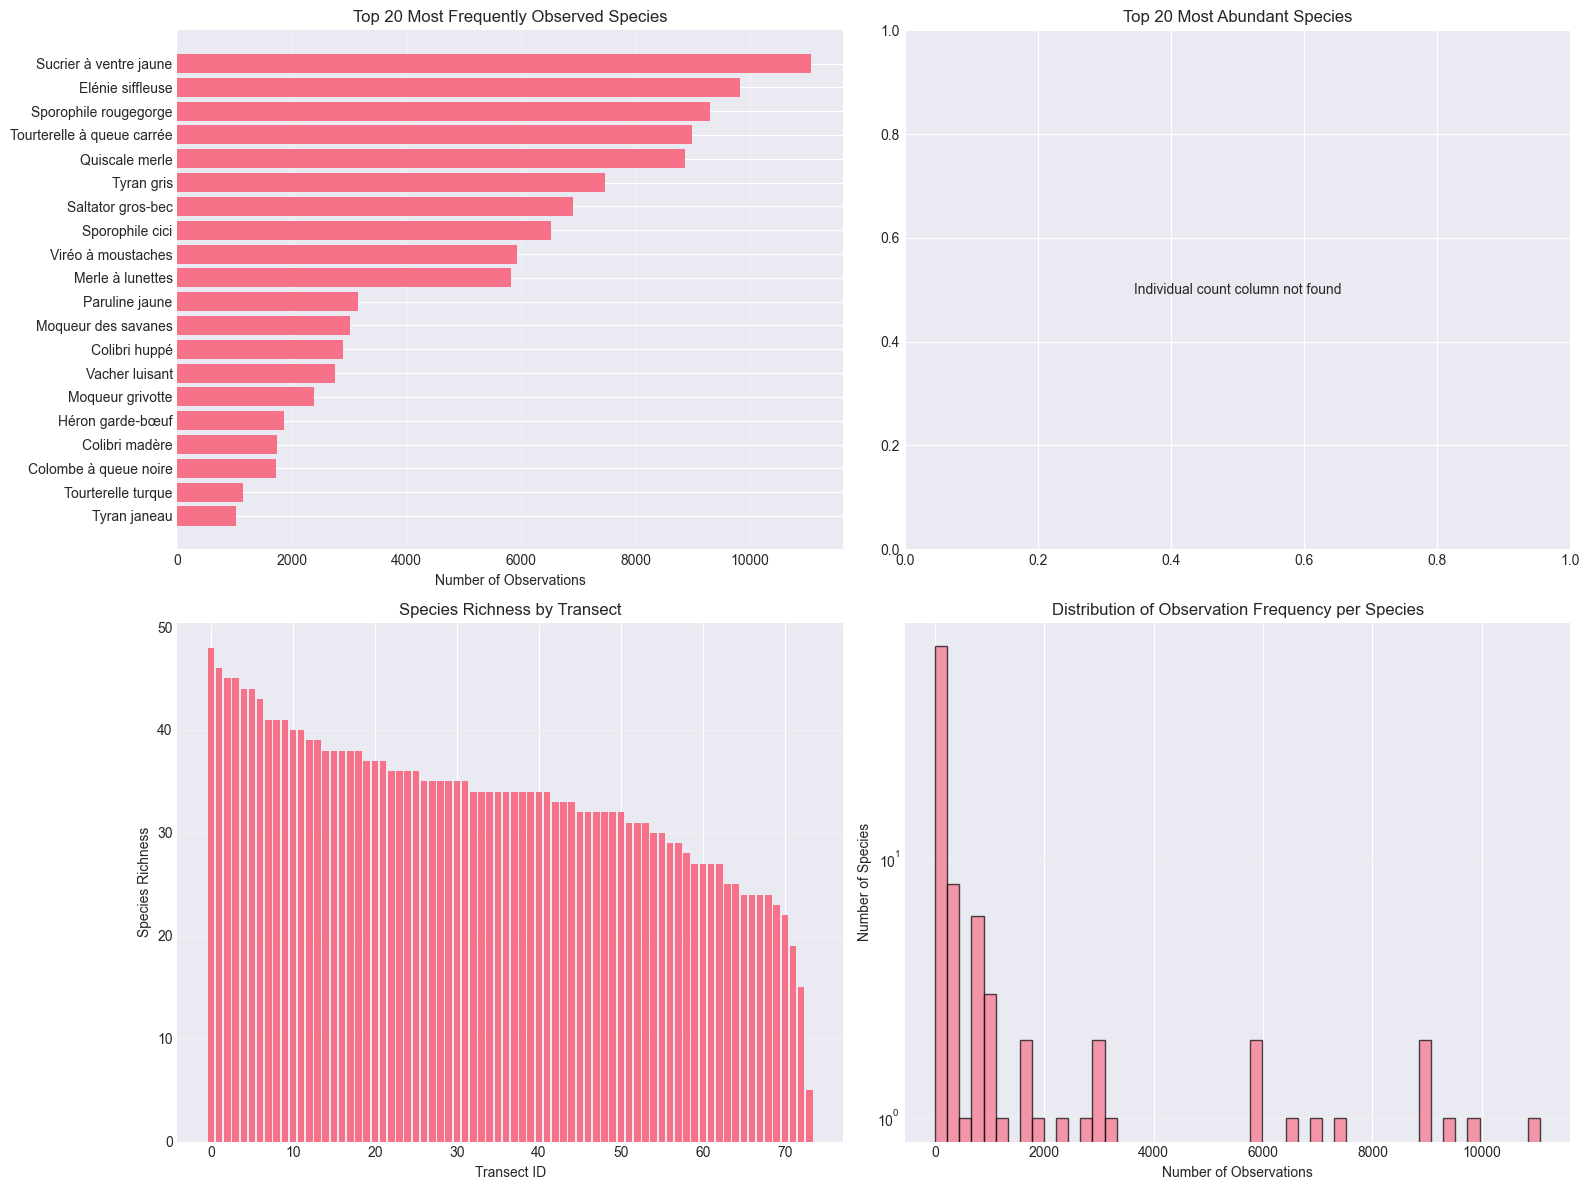

In [ ]:
# Species richness and distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Diagnostic: Check if observations_df exists and has data
print("=" * 80)
print("DIAGNOSTIC INFORMATION")
print("=" * 80)
if 'observations_df' not in globals():
    print("ERROR: observations_df is not defined!")
    print("Please run the data loading cells first.")
else:
    print(f"✓ observations_df exists with {len(observations_df)} rows")
    print(f"✓ Available columns: {list(observations_df.columns)}")
    print(f"✓ First few rows:")
    print(observations_df.head())
    print("=" * 80)

# Identify species column - define at the beginning so it's available throughout
species_col = None

if 'observations_df' in globals() and len(observations_df) > 0:
    if 'species_code' in observations_df.columns:
        species_col = 'species_code'
    elif 'species_name' in observations_df.columns:
        species_col = 'species_name'
    elif 'ESPECE' in observations_df.columns:
        species_col = 'ESPECE'
    else:
        # Try to find any column that might contain species names
        potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
        if potential_cols:
            species_col = potential_cols[0]
            print(f"Using column '{species_col}' for species identification")

    if species_col is None:
        print("Warning: Could not find species column. Please check column names.")
        print(f"Available columns: {list(observations_df.columns)}")
        # Show empty plots with message
        for ax in axes.flat:
            ax.text(0.5, 0.5, 'Species column not found', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print(f"✓ Using species column: '{species_col}'")
        print(f"✓ Number of unique species: {observations_df[species_col].nunique()}")
        
        # 1. Most common species (by observation count)
        species_counts = observations_df[species_col].value_counts().head(20)
        
        if len(species_counts) > 0:
            axes[0, 0].barh(range(len(species_counts)), species_counts.values)
            axes[0, 0].set_yticks(range(len(species_counts)))
            axes[0, 0].set_yticklabels(species_counts.index)
            axes[0, 0].set_xlabel('Number of Observations')
            axes[0, 0].set_title('Top 20 Most Frequently Observed Species')
            axes[0, 0].invert_yaxis()
            axes[0, 0].grid(axis='x', alpha=0.3)
        else:
            axes[0, 0].text(0.5, 0.5, 'No data available', 
                           ha='center', va='center', transform=axes[0, 0].transAxes)
            axes[0, 0].set_title('Top 20 Most Frequently Observed Species')

        # 2. Most abundant species (by individual count)
        if 'individual_count' in observations_df.columns:
            species_abundance = observations_df.groupby(species_col)['individual_count'].sum().sort_values(ascending=False).head(20)
            
            if len(species_abundance) > 0:
                axes[0, 1].barh(range(len(species_abundance)), species_abundance.values)
                axes[0, 1].set_yticks(range(len(species_abundance)))
                axes[0, 1].set_yticklabels(species_abundance.index)
                axes[0, 1].set_xlabel('Total Individuals')
                axes[0, 1].set_title('Top 20 Most Abundant Species')
                axes[0, 1].invert_yaxis()
                axes[0, 1].grid(axis='x', alpha=0.3)
            else:
                axes[0, 1].text(0.5, 0.5, 'No abundance data', 
                               ha='center', va='center', transform=axes[0, 1].transAxes)
                axes[0, 1].set_title('Top 20 Most Abundant Species')
        else:
            axes[0, 1].text(0.5, 0.5, 'Individual count column not found', 
                           ha='center', va='center', transform=axes[0, 1].transAxes)
            axes[0, 1].set_title('Top 20 Most Abundant Species')

        # 3. Species richness by transect
        transect_col = None
        if 'transect_id' in observations_df.columns:
            transect_col = 'transect_id'
        elif 'Nom transect' in observations_df.columns:
            transect_col = 'Nom transect'
        else:
            # Try to find any column with 'transect' in the name
            potential_cols = [col for col in observations_df.columns if 'transect' in col.lower()]
            if potential_cols:
                transect_col = potential_cols[0]
        
        if transect_col:
            richness_by_transect = observations_df.groupby(transect_col)[species_col].nunique().sort_values(ascending=False)
            
            if len(richness_by_transect) > 0:
                axes[1, 0].bar(range(len(richness_by_transect)), richness_by_transect.values)
                axes[1, 0].set_xlabel('Transect ID')
                axes[1, 0].set_ylabel('Species Richness')
                axes[1, 0].set_title('Species Richness by Transect')
                axes[1, 0].grid(axis='y', alpha=0.3)
                
                print(f"Mean species richness per transect: {richness_by_transect.mean():.2f}")
                print(f"Median species richness per transect: {richness_by_transect.median():.2f}")
            else:
                axes[1, 0].text(0.5, 0.5, 'No transect data', 
                               ha='center', va='center', transform=axes[1, 0].transAxes)
                axes[1, 0].set_title('Species Richness by Transect')
        else:
            axes[1, 0].text(0.5, 0.5, 'Transect column not found', 
                           ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 0].set_title('Species Richness by Transect')

        # 4. Species observation frequency distribution
        obs_per_species = observations_df[species_col].value_counts()
        if len(obs_per_species) > 0:
            axes[1, 1].hist(obs_per_species.values, bins=50, edgecolor='black', alpha=0.7)
            axes[1, 1].set_xlabel('Number of Observations')
            axes[1, 1].set_ylabel('Number of Species')
            axes[1, 1].set_title('Distribution of Observation Frequency per Species')
            axes[1, 1].set_yscale('log')
            axes[1, 1].grid(axis='y', alpha=0.3)
        else:
            axes[1, 1].text(0.5, 0.5, 'No observation data', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Distribution of Observation Frequency per Species')

        plt.tight_layout()
        plt.show()
else:
    print("ERROR: observations_df is not defined or is empty!")
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'Data not loaded', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
    plt.tight_layout()
    plt.show()


### 2.3 Temporal Analysis


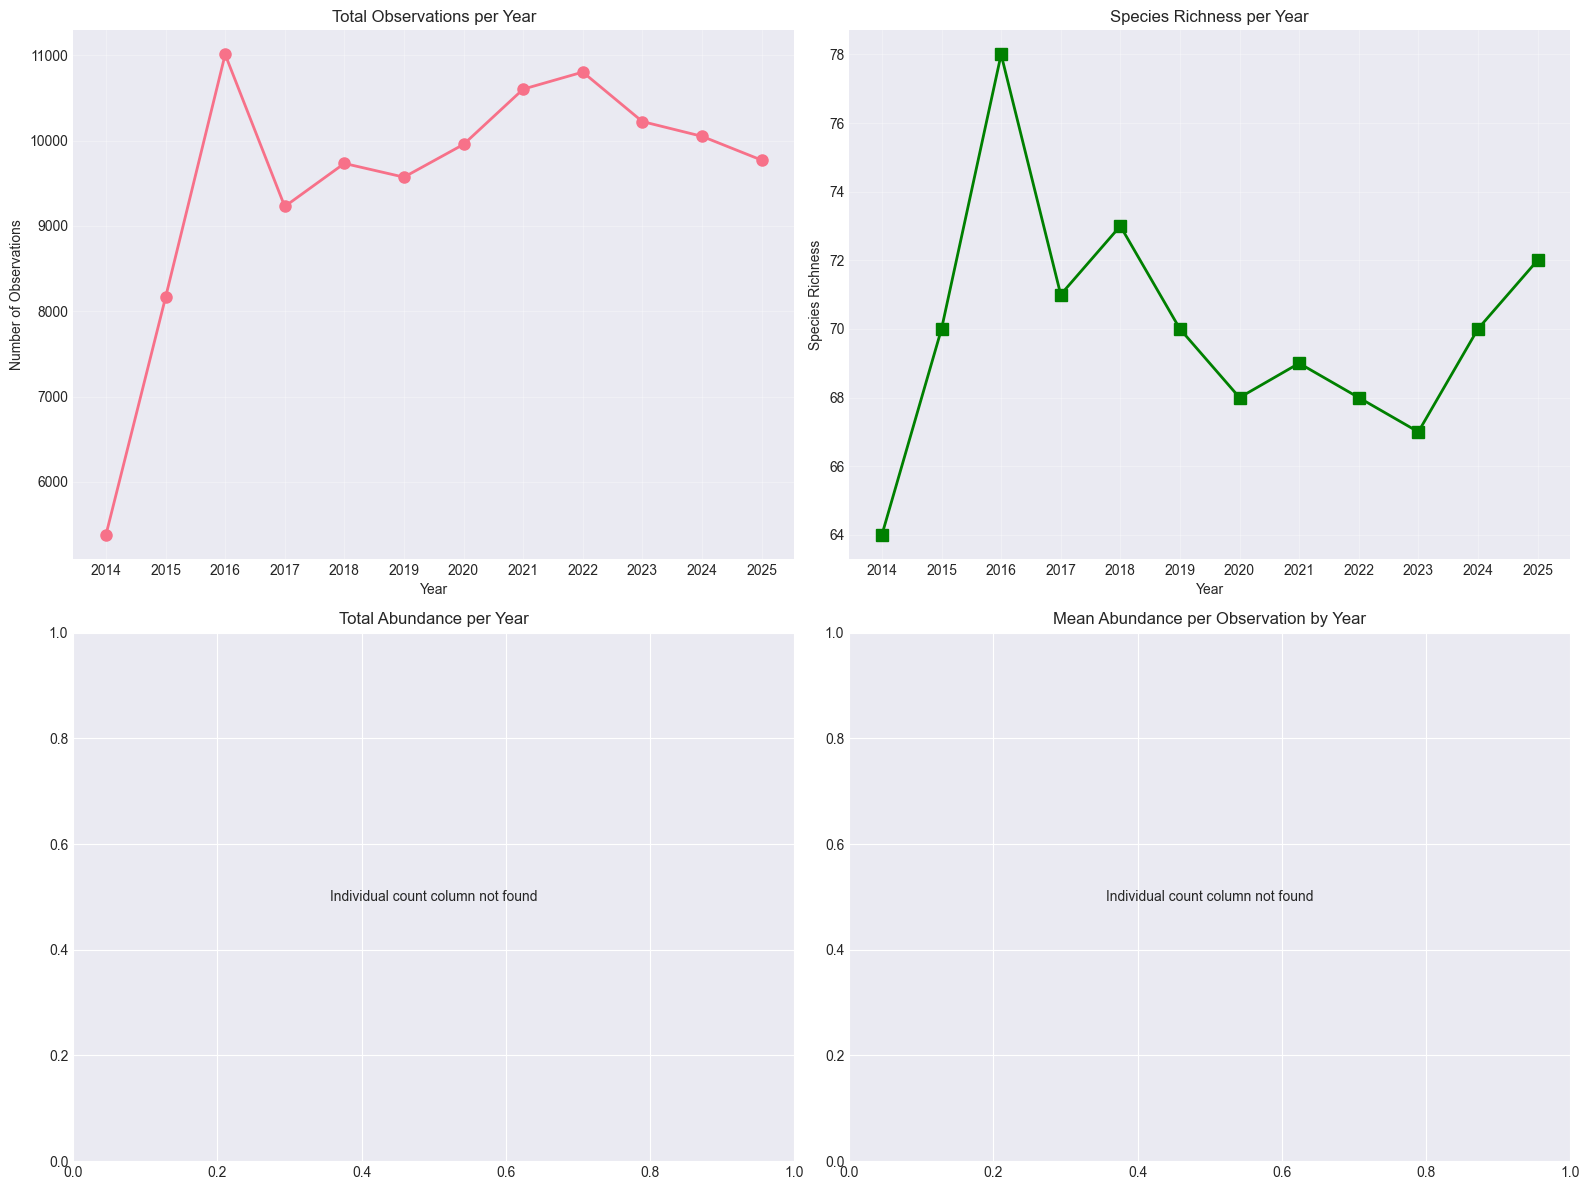

In [ ]:
# Temporal trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")

# Ensure year column exists
if 'year' not in observations_df.columns and 'date' in observations_df.columns:
    observations_df['year'] = pd.to_datetime(observations_df['date']).dt.year
elif 'year' not in observations_df.columns:
    print("Warning: No year or date column found. Please check data structure.")
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'Year column not found', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
    plt.tight_layout()
    plt.show()
elif species_col is None:
    print("Warning: Could not find species column. Please check column names.")
    print(f"Available columns: {list(observations_df.columns)}")
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'Species column not found', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    if 'year' in observations_df.columns:
        # 1. Observations per year
        obs_per_year = observations_df.groupby('year').size()
        if len(obs_per_year) > 0:
            axes[0, 0].plot(obs_per_year.index, obs_per_year.values, marker='o', linewidth=2, markersize=8)
            axes[0, 0].set_xlabel('Year')
            axes[0, 0].set_ylabel('Number of Observations')
            axes[0, 0].set_title('Total Observations per Year')
            axes[0, 0].grid(alpha=0.3)
            axes[0, 0].set_xticks(obs_per_year.index)
        else:
            axes[0, 0].text(0.5, 0.5, 'No data available', 
                           ha='center', va='center', transform=axes[0, 0].transAxes)
            axes[0, 0].set_title('Total Observations per Year')
        
        # 2. Species richness per year
        if species_col and species_col in observations_df.columns:
            richness_per_year = observations_df.groupby('year')[species_col].nunique()
            if len(richness_per_year) > 0:
                axes[0, 1].plot(richness_per_year.index, richness_per_year.values, marker='s', linewidth=2, markersize=8, color='green')
                axes[0, 1].set_xlabel('Year')
                axes[0, 1].set_ylabel('Species Richness')
                axes[0, 1].set_title('Species Richness per Year')
                axes[0, 1].grid(alpha=0.3)
                axes[0, 1].set_xticks(richness_per_year.index)
            else:
                axes[0, 1].text(0.5, 0.5, 'No data available', 
                               ha='center', va='center', transform=axes[0, 1].transAxes)
                axes[0, 1].set_title('Species Richness per Year')
        else:
            axes[0, 1].text(0.5, 0.5, 'Species column not found', 
                           ha='center', va='center', transform=axes[0, 1].transAxes)
            axes[0, 1].set_title('Species Richness per Year')
        
        # 3. Total abundance per year
        if 'individual_count' in observations_df.columns:
            abundance_per_year = observations_df.groupby('year')['individual_count'].sum()
            if len(abundance_per_year) > 0:
                axes[1, 0].plot(abundance_per_year.index, abundance_per_year.values, marker='^', linewidth=2, markersize=8, color='red')
                axes[1, 0].set_xlabel('Year')
                axes[1, 0].set_ylabel('Total Individuals')
                axes[1, 0].set_title('Total Abundance per Year')
                axes[1, 0].grid(alpha=0.3)
                axes[1, 0].set_xticks(abundance_per_year.index)
            else:
                axes[1, 0].text(0.5, 0.5, 'No abundance data', 
                               ha='center', va='center', transform=axes[1, 0].transAxes)
                axes[1, 0].set_title('Total Abundance per Year')
        else:
            axes[1, 0].text(0.5, 0.5, 'Individual count column not found', 
                           ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 0].set_title('Total Abundance per Year')
        
        # 4. Mean abundance per observation per year
        if 'individual_count' in observations_df.columns:
            mean_abundance_per_year = observations_df.groupby('year')['individual_count'].mean()
            if len(mean_abundance_per_year) > 0:
                axes[1, 1].plot(mean_abundance_per_year.index, mean_abundance_per_year.values, marker='d', linewidth=2, markersize=8, color='purple')
                axes[1, 1].set_xlabel('Year')
                axes[1, 1].set_ylabel('Mean Individuals per Observation')
                axes[1, 1].set_title('Mean Abundance per Observation by Year')
                axes[1, 1].grid(alpha=0.3)
                axes[1, 1].set_xticks(mean_abundance_per_year.index)
            else:
                axes[1, 1].text(0.5, 0.5, 'No abundance data', 
                               ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('Mean Abundance per Observation by Year')
        else:
            axes[1, 1].text(0.5, 0.5, 'Individual count column not found', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Mean Abundance per Observation by Year')

    plt.tight_layout()
    plt.show()


Mean species richness per transect: 33.23
Median species richness per transect: 34.00


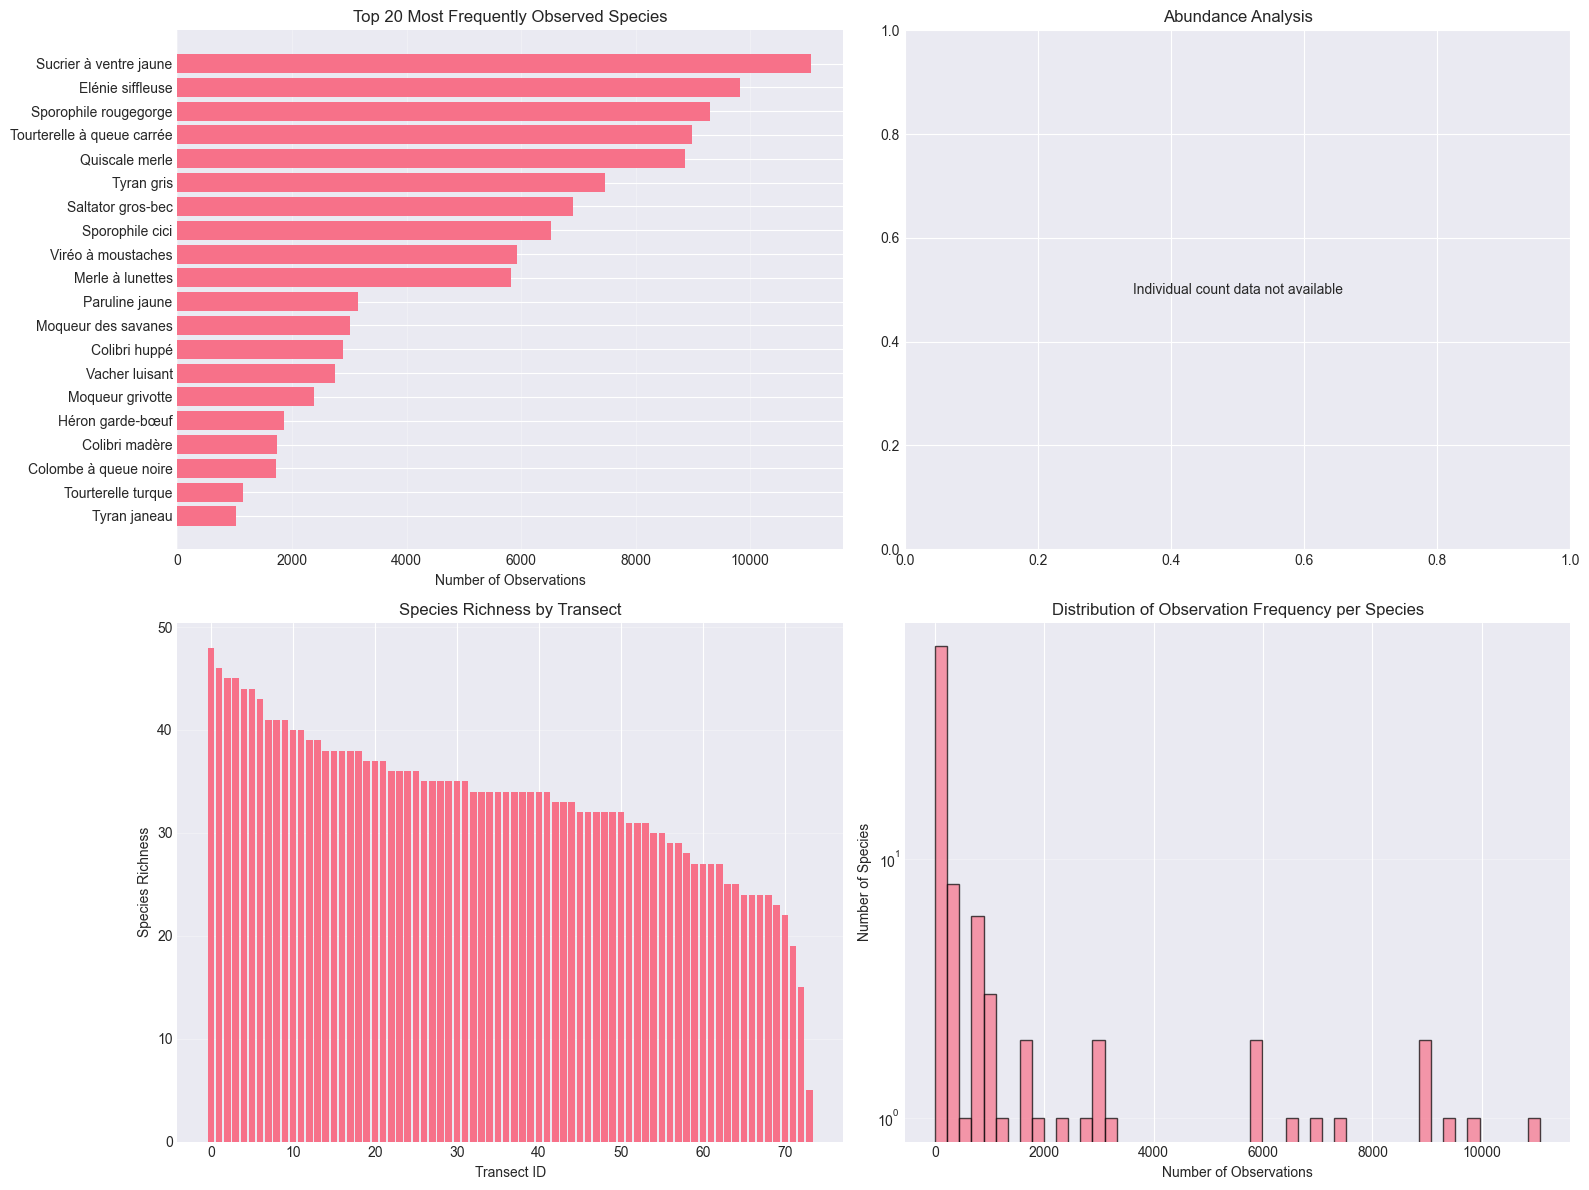

In [ ]:
# Fix for the NameError: name 'species_col' is not defined
# 
# The problem: species_col is defined inside an if block but used later outside that block
# Solution: Define species_col at the beginning of the cell

# REPLACE THE BEGINNING OF YOUR CELL WITH THIS:

# Species richness and distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Identify species column - define at the beginning so it's available throughout
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")

if species_col is None:
    print("Warning: Could not find species column. Please check column names.")
    print(f"Available columns: {list(observations_df.columns)}")
else:
    # 1. Most common species (by observation count)
    species_counts = observations_df[species_col].value_counts().head(20)
    
    axes[0, 0].barh(range(len(species_counts)), species_counts.values)
    axes[0, 0].set_yticks(range(len(species_counts)))
    axes[0, 0].set_yticklabels(species_counts.index)
    axes[0, 0].set_xlabel('Number of Observations')
    axes[0, 0].set_title('Top 20 Most Frequently Observed Species')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # 2. Most abundant species (by individual count)
    if 'individual_count' in observations_df.columns:
        species_abundance = observations_df.groupby(species_col)['individual_count'].sum().sort_values(ascending=False).head(20)
        
        axes[0, 1].barh(range(len(species_abundance)), species_abundance.values)
        axes[0, 1].set_yticks(range(len(species_abundance)))
        axes[0, 1].set_yticklabels(species_abundance.index)
        axes[0, 1].set_xlabel('Total Individuals')
        axes[0, 1].set_title('Top 20 Most Abundant Species')
        axes[0, 1].invert_yaxis()
        axes[0, 1].grid(axis='x', alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'Individual count data not available', 
                        ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Abundance Analysis')

    # 3. Species richness by transect
    # Check for transect column - try different possible names
    transect_col = None
    if 'transect_id' in observations_df.columns:
        transect_col = 'transect_id'
    elif 'Nom transect' in observations_df.columns:
        transect_col = 'Nom transect'
    else:
        potential_cols = [col for col in observations_df.columns if 'transect' in col.lower()]
        if potential_cols:
            transect_col = potential_cols[0]
    
    if transect_col:
        richness_by_transect = observations_df.groupby(transect_col)[species_col].nunique().sort_values(ascending=False)
        
        axes[1, 0].bar(range(len(richness_by_transect)), richness_by_transect.values)
        axes[1, 0].set_xlabel('Transect ID')
        axes[1, 0].set_ylabel('Species Richness')
        axes[1, 0].set_title('Species Richness by Transect')
        axes[1, 0].grid(axis='y', alpha=0.3)
        
        print(f"Mean species richness per transect: {richness_by_transect.mean():.2f}")
        print(f"Median species richness per transect: {richness_by_transect.median():.2f}")
    else:
        axes[1, 0].text(0.5, 0.5, 'Transect data not available', 
                        ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Species Richness by Transect')

    # 4. Species observation frequency distribution
    obs_per_species = observations_df[species_col].value_counts()
    axes[1, 1].hist(obs_per_species.values, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Number of Observations')
    axes[1, 1].set_ylabel('Number of Species')
    axes[1, 1].set_title('Distribution of Observation Frequency per Species')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



### 2.4 Spatial and Habitat Analysis


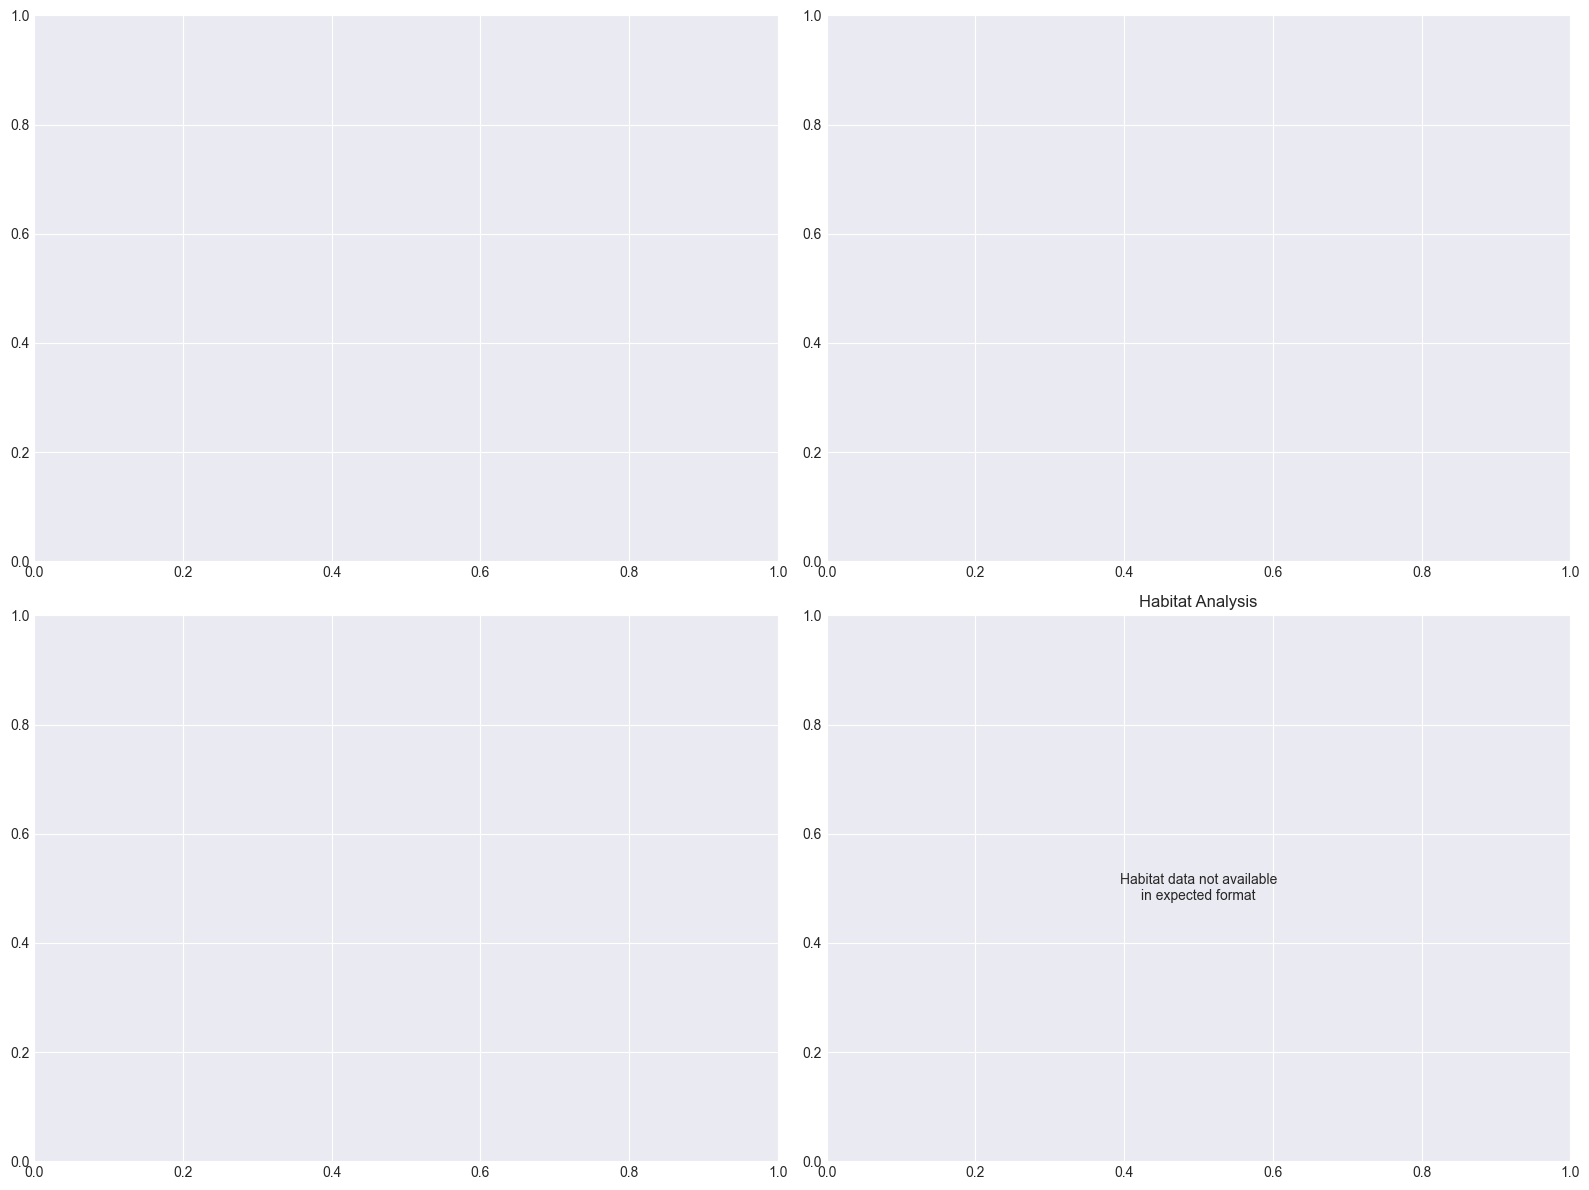

In [ ]:
# Spatial and habitat analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

if 'transect_id' in observations_df.columns:
    # 1. Observations per transect
    obs_per_transect = observations_df.groupby('transect_id').size().sort_values(ascending=False)
    axes[0, 0].bar(range(len(obs_per_transect)), obs_per_transect.values)
    axes[0, 0].set_xlabel('Transect ID')
    axes[0, 0].set_ylabel('Number of Observations')
    axes[0, 0].set_title('Observations per Transect')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Species richness per transect (already shown, but can add more detail)
# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")
    richness_per_transect = observations_df.groupby('transect_id')[species_col].nunique().sort_values(ascending=False)
    axes[0, 1].bar(range(len(richness_per_transect)), richness_per_transect.values, color='green')
    axes[0, 1].set_xlabel('Transect ID')
    axes[0, 1].set_ylabel('Species Richness')
    axes[0, 1].set_title('Species Richness per Transect')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Abundance per transect
    if 'individual_count' in observations_df.columns:
        abundance_per_transect = observations_df.groupby('transect_id')['individual_count'].sum().sort_values(ascending=False)
        axes[1, 0].bar(range(len(abundance_per_transect)), abundance_per_transect.values, color='red')
        axes[1, 0].set_xlabel('Transect ID')
        axes[1, 0].set_ylabel('Total Individuals')
        axes[1, 0].set_title('Total Abundance per Transect')
        axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Habitat analysis (if habitat column exists in merged data or GPS-MILIEU)
if 'habitat' in gps_milieu_df.columns or 'milieu' in gps_milieu_df.columns:
    habitat_col = 'habitat' if 'habitat' in gps_milieu_df.columns else 'milieu'
    habitat_counts = gps_milieu_df[habitat_col].value_counts()
    axes[1, 1].barh(range(len(habitat_counts)), habitat_counts.values)
    axes[1, 1].set_yticks(range(len(habitat_counts)))
    axes[1, 1].set_yticklabels(habitat_counts.index)
    axes[1, 1].set_xlabel('Number of Sites')
    axes[1, 1].set_title('Habitat Type Distribution')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Habitat data not available\nin expected format', 
                     ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Habitat Analysis')

plt.tight_layout()
plt.show()


### 2.5 Observer and Detection Modality Analysis


In [ ]:
# Observer and detection analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Observer workload
if 'observer_id' in observations_df.columns:
    obs_per_observer = observations_df.groupby('observer_id').size().sort_values(ascending=False)
    top_observers = obs_per_observer.head(15)
    axes[0, 0].barh(range(len(top_observers)), top_observers.values)
    axes[0, 0].set_yticks(range(len(top_observers)))
    axes[0, 0].set_yticklabels(top_observers.index)
    axes[0, 0].set_xlabel('Number of Observations')
    axes[0, 0].set_title('Top 15 Observers by Observation Count')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    print(f"Total observers: {observations_df['observer_id'].nunique()}")
    print(f"Mean observations per observer: {obs_per_observer.mean():.2f}")

# 2. Detection modality distribution
if 'detection_type' in observations_df.columns:
    detection_counts = observations_df['detection_type'].value_counts()
    axes[0, 1].pie(detection_counts.values, labels=detection_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Distribution of Detection Types')
    
    print(f"\nDetection type distribution:")
    print(detection_counts)
else:
    axes[0, 1].text(0.5, 0.5, 'Detection type data\nnot available', 
                     ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Detection Type Analysis')

# 3. Detection modality by species (if available)
if 'detection_type' in observations_df.columns:
# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")
    detection_by_species = pd.crosstab(observations_df[species_col], observations_df['detection_type'])
    top_species_detection = detection_by_species.sum(axis=1).sort_values(ascending=False).head(10)
    detection_by_species_top = detection_by_species.loc[top_species_detection.index]
    
    detection_by_species_top.plot(kind='bar', stacked=True, ax=axes[1, 0], width=0.8)
    axes[1, 0].set_xlabel('Species')
    axes[1, 0].set_ylabel('Number of Observations')
    axes[1, 0].set_title('Detection Modality for Top 10 Species')
    axes[1, 0].legend(title='Detection Type')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Observer detection rates (if both available)
if 'observer_id' in observations_df.columns and 'detection_type' in observations_df.columns:
    observer_detection = pd.crosstab(observations_df['observer_id'], observations_df['detection_type'])
    # Normalize to percentages
    observer_detection_pct = observer_detection.div(observer_detection.sum(axis=1), axis=0) * 100
    top_observers_ids = obs_per_observer.head(10).index
    observer_detection_pct_top = observer_detection_pct.loc[top_observers_ids]
    
    observer_detection_pct_top.plot(kind='bar', stacked=True, ax=axes[1, 1], width=0.8)
    axes[1, 1].set_xlabel('Observer ID')
    axes[1, 1].set_ylabel('Percentage of Observations')
    axes[1, 1].set_title('Detection Modality Distribution for Top 10 Observers')
    axes[1, 1].legend(title='Detection Type')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


IndentationError: expected an indented block after 'if' statement on line 33 (2709048527.py, line 35)

## Task 3: Statistical Modeling and Analysis

### 3.1 Trend Analysis


## Research Questions and Hypotheses

Before proceeding with statistical modeling, we need to define clear research questions and hypotheses based on the objectives of analyzing Martinique breeding bird monitoring data.

### Research Questions

1. **Temporal Trends**: Have bird populations (abundance and species richness) changed significantly over the monitoring period (2012-2025)?

2. **Habitat Relationships**: Do different habitat types support different bird communities in terms of species composition, richness, and abundance?

3. **Species-Specific Trends**: Are there significant population trends for individual bird species, and which species are declining or increasing?

4. **Spatial Patterns**: Are there spatial patterns in bird diversity across the island, and do certain transects or regions show higher biodiversity?

5. **Observer and Detection Effects**: Do observer characteristics or detection methods (visual vs. audio) significantly affect detection rates and abundance estimates?

### Hypotheses

#### H1: Temporal Trends in Species Richness
- **H₀**: There is no significant change in species richness over time (2012-2025)
- **H₁**: Species richness has changed significantly over the monitoring period
- **Test**: Linear regression with year as predictor, t-test on slope coefficient

#### H2: Temporal Trends in Total Abundance
- **H₀**: There is no significant change in total bird abundance over time (2012-2025)
- **H₁**: Total bird abundance has changed significantly over the monitoring period
- **Test**: Linear regression with year as predictor, t-test on slope coefficient

#### H3: Habitat Effects on Species Richness
- **H₀**: Species richness does not differ significantly between habitat types
- **H₁**: Species richness differs significantly between at least two habitat types
- **Test**: ANOVA or Kruskal-Wallis test (if assumptions not met)

#### H4: Habitat Effects on Abundance
- **H₀**: Bird abundance does not differ significantly between habitat types
- **H₁**: Bird abundance differs significantly between at least two habitat types
- **Test**: ANOVA or Kruskal-Wallis test (if assumptions not met)

#### H5: Species-Specific Population Trends
- **H₀**: For each species, there is no significant temporal trend in abundance
- **H₁**: For some species, there are significant temporal trends (increasing or decreasing)
- **Test**: Linear regression for each species with sufficient data, multiple testing correction (Bonferroni or FDR)

#### H6: Observer Effects on Detection
- **H₀**: Observer identity does not significantly affect detection rates
- **H₁**: Observer identity significantly affects detection rates
- **Test**: Mixed-effects model or ANOVA with observer as random/fixed effect

#### H7: Detection Modality Effects
- **H₀**: Detection rates do not differ significantly between visual and audio detection methods
- **H₁**: Detection rates differ significantly between visual and audio methods
- **Test**: Chi-square test or logistic regression

#### H8: Spatial Patterns in Biodiversity
- **H₀**: Species richness and abundance are uniformly distributed across transects
- **H₁**: There are significant spatial patterns in species richness and abundance
- **Test**: Spatial autocorrelation analysis, clustering analysis

### Statistical Approach

- **Significance level**: α = 0.05 for all tests
- **Multiple testing correction**: Bonferroni or False Discovery Rate (FDR) when testing multiple hypotheses
- **Model assumptions**: All models will be checked for assumptions (normality, homoscedasticity, independence)
- **Effect sizes**: Will be reported alongside p-values for practical significance



In [ ]:
# Statistical trend analysis
from scipy import stats
from scipy.stats import linregress

print("=" * 80)
print("STATISTICAL TREND ANALYSIS")
print("=" * 80)

if 'year' in observations_df.columns:
    # Identify species column
    species_col = None
    if 'species_code' in observations_df.columns:
        species_col = 'species_code'
    elif 'species_name' in observations_df.columns:
        species_col = 'species_name'
    elif 'ESPECE' in observations_df.columns:
        species_col = 'ESPECE'
    else:
        potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
        if potential_cols:
            species_col = potential_cols[0]
    
    if species_col is None:
        print("Error: Could not find species column")
        print(f"Available columns: {list(observations_df.columns)}")
    else:
        # Ensure year column exists (extract from date if needed)
        if 'year' not in observations_df.columns:
            if 'date' in observations_df.columns:
                observations_df['year'] = pd.to_datetime(observations_df['date'], errors='coerce').dt.year
            else:
                print("Error: No year or date column found")
                year_col = None
        else:
            year_col = 'year'
        
        if year_col:
            # Build aggregation dictionary dynamically
            agg_dict = {species_col: 'nunique'}
            
            # Add individual_count if it exists
            count_col = None
            if 'individual_count' in observations_df.columns:
                count_col = 'individual_count'
                agg_dict[count_col] = ['sum', 'mean']
            elif 'totaux' in observations_df.columns:
                count_col = 'totaux'
                agg_dict[count_col] = ['sum', 'mean']
            
            # Yearly aggregates
            yearly_data = observations_df.groupby(year_col).agg(agg_dict).reset_index()
            
            # Rename columns
            if count_col:
                yearly_data.columns = [year_col, 'richness', 'total_abundance', 'mean_abundance']
            else:
                yearly_data.columns = [year_col, 'richness']
            
            # Rename year column for consistency
            if year_col != 'year':
                yearly_data = yearly_data.rename(columns={year_col: 'year'})
# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")
    
    # Yearly aggregates
    yearly_data = observations_df.groupby('year').agg({
        species_col: 'nunique',  # Species richness
        'individual_count': ['sum', 'mean'] if 'individual_count' in observations_df.columns else 'count'
    }).reset_index()
    
    yearly_data.columns = ['year', 'richness', 'total_abundance', 'mean_abundance'] if 'individual_count' in observations_df.columns else ['year', 'richness', 'total_obs']
    
    # Linear regression for species richness trend
    years = yearly_data['year'].values
    richness = yearly_data['richness'].values
    
    slope_richness, intercept_richness, r_value_richness, p_value_richness, std_err_richness = linregress(years, richness)
    
    print(f"\n1. Species Richness Trend (2012-2025):")
    print(f"   - Slope: {slope_richness:.4f} species/year")
    print(f"   - R-squared: {r_value_richness**2:.4f}")
    print(f"   - P-value: {p_value_richness:.4f}")
    if p_value_richness < 0.05:
        print(f"   - Result: Significant trend (p < 0.05)")
        direction = "increasing" if slope_richness > 0 else "decreasing"
        print(f"   - Direction: {direction}")
    else:
        print(f"   - Result: No significant trend (p >= 0.05)")
    
    # Linear regression for abundance trend (if available)
    if 'total_abundance' in yearly_data.columns:
        abundance = yearly_data['total_abundance'].values
        slope_abundance, intercept_abundance, r_value_abundance, p_value_abundance, std_err_abundance = linregress(years, abundance)
        
        print(f"\n2. Total Abundance Trend (2012-2025):")
        print(f"   - Slope: {slope_abundance:.4f} individuals/year")
        print(f"   - R-squared: {r_value_abundance**2:.4f}")
        print(f"   - P-value: {p_value_abundance:.4f}")
        if p_value_abundance < 0.05:
            print(f"   - Result: Significant trend (p < 0.05)")
            direction = "increasing" if slope_abundance > 0 else "decreasing"
            print(f"   - Direction: {direction}")
        else:
            print(f"   - Result: No significant trend (p >= 0.05)")
    
    # Visualization with trend lines
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].scatter(years, richness, s=100, alpha=0.7, label='Observed')
    axes[0].plot(years, intercept_richness + slope_richness * years, 
                 'r--', linewidth=2, label=f'Trend (R²={r_value_richness**2:.3f})')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Species Richness')
    axes[0].set_title('Species Richness Trend Over Time')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    if 'total_abundance' in yearly_data.columns:
        axes[1].scatter(years, abundance, s=100, alpha=0.7, label='Observed', color='green')
        axes[1].plot(years, intercept_abundance + slope_abundance * years, 
                     'r--', linewidth=2, label=f'Trend (R²={r_value_abundance**2:.3f})')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Total Abundance')
        axes[1].set_title('Total Abundance Trend Over Time')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


STATISTICAL TREND ANALYSIS


KeyError: "Column(s) ['individual_count', 'species_name'] do not exist"

### 3.2 Habitat Analysis


In [ ]:
# Habitat analysis (if habitat data is available after merging)
# This section assumes you've merged the GPS-MILIEU data with observations

print("=" * 80)
print("HABITAT ANALYSIS")
print("=" * 80)

# Note: This requires merging GPS-MILIEU with observations first
# Adjust based on actual merged dataset structure

print("\nNote: To perform habitat analysis, merge GPS-MILIEU sheet with observations.")
print("Example code (adjust column names):")
print("""
# Merge observations with site information
merged_df = observations_df.merge(
    gps_milieu_df,
    left_on=['transect_id', 'point_id'],
    right_on=['transect_id', 'point_id'],
    how='left'
)

# Then analyze by habitat
if 'habitat' in merged_df.columns:
    habitat_richness = merged_df.groupby('habitat')['species_code'].nunique()
    habitat_abundance = merged_df.groupby('habitat')['individual_count'].sum()
    
    # Statistical tests (e.g., ANOVA)
    from scipy.stats import f_oneway
    habitats = merged_df['habitat'].unique()
    groups = [merged_df[merged_df['habitat'] == h]['individual_count'] for h in habitats]
    f_stat, p_value = f_oneway(*groups)
    
    print(f"ANOVA test for abundance differences between habitats:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
""")


### 3.3 Species-Specific Analysis


In [ ]:
# Analyze trends for individual species
print("=" * 80)
print("SPECIES-SPECIFIC TREND ANALYSIS")
print("=" * 80)

if 'year' in observations_df.columns:
# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")
    
    # Get top 10 most frequently observed species
    top_species = observations_df[species_col].value_counts().head(10).index
    
    # Analyze trends for each species
    species_trends = []
    
    for species in top_species:
        species_data = observations_df[observations_df[species_col] == species]
        yearly_counts = species_data.groupby('year').size()
        
        if len(yearly_counts) >= 3:  # Need at least 3 years for trend analysis
            years = yearly_counts.index.values
            counts = yearly_counts.values
            
            slope, intercept, r_value, p_value, std_err = linregress(years, counts)
            
            species_trends.append({
                'species': species,
                'slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend': 'increasing' if slope > 0 and p_value < 0.05 else ('decreasing' if slope < 0 and p_value < 0.05 else 'stable'),
                'mean_count': counts.mean()
            })
    
    trends_df = pd.DataFrame(species_trends)
    trends_df = trends_df.sort_values('p_value')
    
    print("\nSpecies-specific trends (top 10 most observed species):")
    display(trends_df)
    
    # Visualize trends for species with significant changes
    significant_species = trends_df[trends_df['p_value'] < 0.05]
    
    if len(significant_species) > 0:
        n_species = min(len(significant_species), 6)
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for idx, (_, row) in enumerate(significant_species.head(n_species).iterrows()):
            species = row['species']
            species_data = observations_df[observations_df[species_col] == species]
            yearly_counts = species_data.groupby('year').size()
            
            years = yearly_counts.index.values
            counts = yearly_counts.values
            
            axes[idx].plot(years, counts, marker='o', linewidth=2, markersize=8)
            
            # Add trend line
            slope = row['slope']
            intercept = np.mean(counts) - slope * np.mean(years)
            axes[idx].plot(years, intercept + slope * years, 'r--', linewidth=2, alpha=0.7)
            
            axes[idx].set_xlabel('Year')
            axes[idx].set_ylabel('Observations')
            axes[idx].set_title(f"{species}\n({row['trend']}, p={row['p_value']:.3f})")
            axes[idx].grid(alpha=0.3)
        
        # Hide unused subplots
        for idx in range(n_species, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo species showed significant trends (p < 0.05) in the top 10 most observed species.")


## Task 4: Advanced Analysis

### 4.1 Generalized Linear Models (GLMs)


In [ ]:
# Advanced statistical modeling using GLMs
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families

print("=" * 80)
print("GENERALIZED LINEAR MODELS (GLMs)")
print("=" * 80)

# Prepare data for modeling
if 'year' in observations_df.columns and 'individual_count' in observations_df.columns:
    # Aggregate data by year and transect for modeling
    model_data = observations_df.groupby(['year', 'transect_id']).agg({
        'individual_count': 'sum',
        'species_code': 'nunique' if 'species_code' in observations_df.columns else 'count'
    }).reset_index()
    
    model_data.columns = ['year', 'transect_id', 'abundance', 'richness']
    
    # Prepare features
    X = model_data[['year']].copy()
    X['year_centered'] = X['year'] - X['year'].mean()  # Center year for better interpretation
    y = model_data['abundance']
    
    # Fit Poisson GLM (appropriate for count data)
    try:
        X_with_const = sm.add_constant(X[['year_centered']])
        glm_poisson = GLM(y, X_with_const, family=families.Poisson())
        glm_result = glm_poisson.fit()
        
        print("\nPoisson GLM Results for Abundance:")
        print(glm_result.summary())
        
        # Predictions
        predictions = glm_result.predict(X_with_const)
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Observed vs predicted
        axes[0].scatter(y, predictions, alpha=0.6)
        axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
        axes[0].set_xlabel('Observed Abundance')
        axes[0].set_ylabel('Predicted Abundance')
        axes[0].set_title('Poisson GLM: Observed vs Predicted')
        axes[0].grid(alpha=0.3)
        
        # Trend over time
        yearly_pred = pd.DataFrame({
            'year': X['year'],
            'predicted': predictions
        }).groupby('year')['predicted'].mean()
        
        axes[1].plot(yearly_pred.index, yearly_pred.values, marker='o', linewidth=2, label='Predicted')
        axes[1].scatter(model_data['year'], model_data['abundance'], alpha=0.5, label='Observed')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Abundance')
        axes[1].set_title('Poisson GLM: Abundance Trend')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error fitting GLM: {e}")
        print("This may be due to data structure. Please check your merged dataset.")
else:
    print("Required columns (year, individual_count) not found for GLM analysis.")


### 4.2 Community Analysis


In [ ]:
# Community composition analysis
print("=" * 80)
print("COMMUNITY ANALYSIS")
print("=" * 80)

if 'transect_id' in observations_df.columns:
# Identify species column - use robust detection
species_col = None
if 'species_code' in observations_df.columns:
    species_col = 'species_code'
elif 'species_name' in observations_df.columns:
    species_col = 'species_name'
elif 'ESPECE' in observations_df.columns:
    species_col = 'ESPECE'
else:
    # Try to find any column that might contain species names
    potential_cols = [col for col in observations_df.columns if 'espece' in col.lower() or 'species' in col.lower()]
    if potential_cols:
        species_col = potential_cols[0]
        print(f"Using column '{species_col}' for species identification")
    
    # Create species-transect matrix (presence/absence or abundance)
    if 'individual_count' in observations_df.columns:
        # Abundance matrix
        community_matrix = observations_df.pivot_table(
            index='transect_id',
            columns=species_col,
            values='individual_count',
            aggfunc='sum',
            fill_value=0
        )
    else:
        # Presence/absence matrix
        community_matrix = pd.crosstab(observations_df['transect_id'], observations_df[species_col])
    
    print(f"\nCommunity matrix shape: {community_matrix.shape}")
    print(f"  - Transects: {community_matrix.shape[0]}")
    print(f"  - Species: {community_matrix.shape[1]}")
    
    # Calculate diversity indices
    from scipy.stats import entropy
    
    diversity_metrics = []
    for transect in community_matrix.index:
        abundances = community_matrix.loc[transect].values
        abundances = abundances[abundances > 0]  # Remove zeros
        
        # Species richness
        richness = len(abundances)
        
        # Shannon diversity index
        proportions = abundances / abundances.sum()
        shannon = -np.sum(proportions * np.log(proportions))
        
        # Simpson diversity index
        simpson = 1 - np.sum((abundances / abundances.sum())**2)
        
        diversity_metrics.append({
            'transect_id': transect,
            'richness': richness,
            'shannon': shannon,
            'simpson': simpson
        })
    
    diversity_df = pd.DataFrame(diversity_metrics)
    
    print("\nDiversity Metrics Summary:")
    print(diversity_df.describe())
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].hist(diversity_df['richness'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Species Richness')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Species Richness')
    axes[0].grid(alpha=0.3)
    
    axes[1].hist(diversity_df['shannon'], bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_xlabel('Shannon Diversity Index')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Shannon Diversity')
    axes[1].grid(alpha=0.3)
    
    axes[2].hist(diversity_df['simpson'], bins=20, edgecolor='black', alpha=0.7, color='red')
    axes[2].set_xlabel('Simpson Diversity Index')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Distribution of Simpson Diversity')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation between diversity metrics
    print("\nCorrelation between diversity metrics:")
    print(diversity_df[['richness', 'shannon', 'simpson']].corr())


COMMUNITY ANALYSIS


## Task 5: Results Summary and Conclusions

### 5.1 Key Findings Summary


In [ ]:
# Generate comprehensive summary report
print("=" * 80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 80)

summary_report = {
    'Dataset Information': {
        'Total Observations': len(observations_df),
        'Total Species': observations_df[species_col].nunique() if 'species_code' in observations_df.columns or 'species_name' in observations_df.columns else 'N/A',
        'Total Transects': observations_df['transect_id'].nunique() if 'transect_id' in observations_df.columns else 'N/A',
        'Years Covered': f"{observations_df['year'].min()}-{observations_df['year'].max()}" if 'year' in observations_df.columns else 'N/A'
    }
}

if 'individual_count' in observations_df.columns:
    summary_report['Abundance Metrics'] = {
        'Total Individuals': int(observations_df['individual_count'].sum()),
        'Mean per Observation': round(observations_df['individual_count'].mean(), 2),
        'Median per Observation': round(observations_df['individual_count'].median(), 2)
    }

if 'year' in observations_df.columns:
    # Calculate trends
    yearly_richness = observations_df.groupby('year')[species_col].nunique()
    slope_r, _, r_r, p_r, _ = linregress(yearly_richness.index, yearly_richness.values)
    
    if 'individual_count' in observations_df.columns:
        yearly_abundance = observations_df.groupby('year')['individual_count'].sum()
        slope_a, _, r_a, p_a, _ = linregress(yearly_abundance.index, yearly_abundance.values)
        
        summary_report['Temporal Trends'] = {
            'Species Richness Trend': f"{'Increasing' if slope_r > 0 else 'Decreasing'} ({slope_r:.2f} species/year, p={p_r:.4f})",
            'Abundance Trend': f"{'Increasing' if slope_a > 0 else 'Decreasing'} ({slope_a:.2f} individuals/year, p={p_a:.4f})"
        }

# Print summary
for section, data in summary_report.items():
    print(f"\n{section}:")
    print("-" * 40)
    for key, value in data.items():
        print(f"  {key}: {value}")

print("\n" + "=" * 80)
print("Analysis complete! Review the visualizations and statistics above.")
print("=" * 80)


## References and Data Citation

**Data Source:** Martinique Breeding Bird Monitoring, 2012–2025

**Analysis Date:** {datetime.now().strftime('%Y-%m-%d')}

**Analysis Tools:**
- Python 3.x
- pandas, numpy, matplotlib, seaborn
- scipy, statsmodels
- scikit-learn

---

## Notes

1. **Column Names**: This notebook uses generic column names. Please adjust column names based on your actual data structure.

2. **Data Merging**: Ensure you merge the three sheets (ESPECES, GPS-MILIEU, NOM FRANÇAIS) appropriately before advanced analyses.

3. **Missing Data**: Handle missing values appropriately based on your analysis needs.

4. **Statistical Tests**: All statistical tests assume appropriate assumptions are met. Verify assumptions before interpreting results.

5. **Reproducibility**: Save this notebook and ensure all data paths are correct for reproducibility.
